# **Fundamentos de Ciencia de Datos**
### **Sesión práctica # 1**
### **Definición de la base de datos y visualización básica**
### *Juan Manuel Velásquez Castañeda - 1037856273*

# **Importaciones**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import zipfile
from google.colab import drive

# **Subir los datos**

In [2]:
#ejecutar despues de subir el zip del local

os.makedirs("data", exist_ok=True)

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

drive.mount('/content/drive')

Mounted at /content/drive


# **Definición del problema**
*El problema a tratar en esta investigación será el análisis de los factores socioeconómicos - demográficos y su influencia en las muertes del Titanic.*


El Titanic, el catalogado buque más grande en esos tiempos (1912), colisionó contra un iceberg, el cual instantes después sería el generador de su hundimiento, llevándose la vida de miles de pasajeros y tripulantes. Se puede decir que la causa de tan alto índice de mortalidad en el accidente ocurrió mayormente por malas decisiones técnicas, operativas o normativas que exigieran, por ejemplo, un número de botes suficiente para el total de personas que abordaron, pero si ahondamos más en el problema, nos damos cuenta de que hubo varios factores que influenciaron en la probabilidad de supervivencia de algunos grupos de personas en específico.

---

### **Selección de la base de datos**

Para llevar acabo esta investigación se selecciona una base de datos que recopila información de pasajeros en el barco, como su sexo `(Sex)`, edad `(Age)`, tipo de boleto `(Pclass)`, número de hermanos o conyugues abordo `(SibSp)`, tarifa `(Fare)`, la cabina `(Cabin)`, si sovrevivio o no `(Survived)`, etc. Esto es clave para descubrir las causas que se asosian al incide de supervivencia en el accidente.

# **Creación del dataframe y una breve visualización de los datos**

In [3]:
df = pd.read_csv("data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
# **Número de registros en el dataset**

In [ ]:
print(f"Número de filas/columnas en el dataframe: {df.shape}")

Número de filas/columnas en el dataframe: (891, 12)


---
# **Informacipon detallada del dataframe**
(El tipo de dato para cada columna y tambien se visualizan el número de valores que no son faltantes en cada columna)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


---
# **Estadisticas basicas de variables en el dataframe**



In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Identificación y clasificación de las variables**

**Variables numéricas:**

In [ ]:
numerica = df.select_dtypes(include=["int64", "float64"]).columns.to_list()

categorica = df.select_dtypes(include=["object"]).columns.to_list()

print(f"Variables numéricas: {numerica}")
print(f"Variables categóricas: {categorica}")

Variables numéricas: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Variables categóricas: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


---
# **Identificación de variables clave**

Porcentaje de faltantes en cada variable:

In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Conteo de faltantes en cada variable:

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


---
# Selección **manual** de variables con alta importancia

*El problema a tratar en esta investigación será el análisis de los factores socioeconómicos - demográficos y su influencia en las muertes del Titanic.*

**¿Que paso por mi mente al seleccioanr estas variables?**

Survived: Mi objetivo aqui
* Pclass: Me interesa estudiar relaciones con la clase del tiquete ¿Influye tener primera clase? ¿Mas money?
* Sex: ¿Primero mujeres y niños? Demografico
* Age: A pesar de tener aprox 20% de nulos para mi es representativa. ¿Influye la edad?

* SibSp: Tambien me interesa saber la influencia de cantidad de hermanos y conyugues a bordo en la muerte.
* Parch: Al igual que la anterior. ¿Influye el numero de padres e hijos a bordo?
* Fare: Que tanto pago el pasajero, si pago mas tenia mas probabilidad de sobrevivir?
* Embarked: Y el puerto de embarque, el puerto en el que se embarca puede tener relación a la clase, y por ende influye en su supervivencia.

In [ ]:
variables_clave = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

print(df[variables_clave].head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


---
# **Visualizaciones para comprension inicial de los datos**

**Pasajeros por clase**

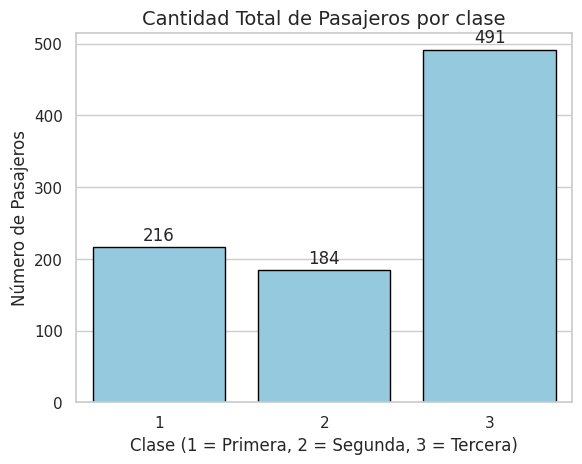

In [ ]:
sns.countplot(data=df, x='Pclass', color='skyblue', edgecolor='black')

plt.title('Cantidad Total de Pasajeros por clase', fontsize=14)
plt.xlabel('Clase (1 = Primera, 2 = Segunda, 3 = Tercera)', fontsize=12)
plt.ylabel('Número de Pasajeros', fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points')

plt.show()

---
**Supervivencia por clase**


In [ ]:
df['Sobrevivio'] = df['Survived'].map({0: 'No', 1: 'Sí'})

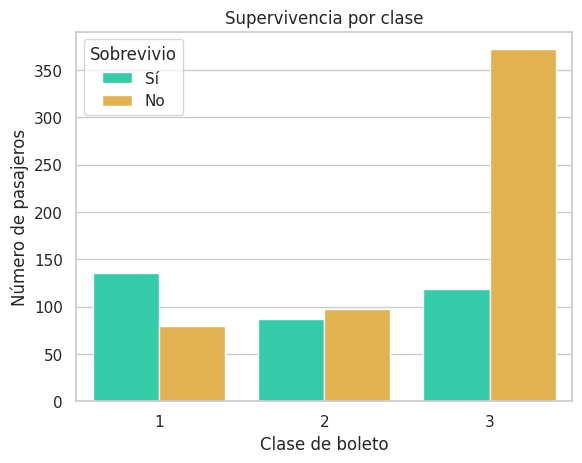

In [ ]:
sns.countplot(data=df, x="Pclass", hue="Sobrevivio", palette="turbo")
plt.title("Supervivencia por clase")
plt.xlabel("Clase de boleto")
plt.ylabel("Número de pasajeros")
plt.show()

---
**Grafico de barras: Número de hombres vs número de mujeres**

/tmp/ipython-input-1032/2220288148.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sex", palette="turbo")


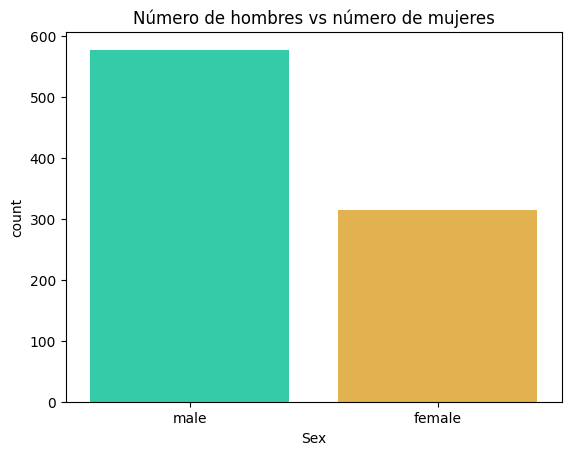

In [5]:
sns.countplot(data=df, x="Sex", palette="turbo")
plt.title("Número de hombres vs número de mujeres")
plt.show()

---
**Grafico de barras: Supervivencia por genero**

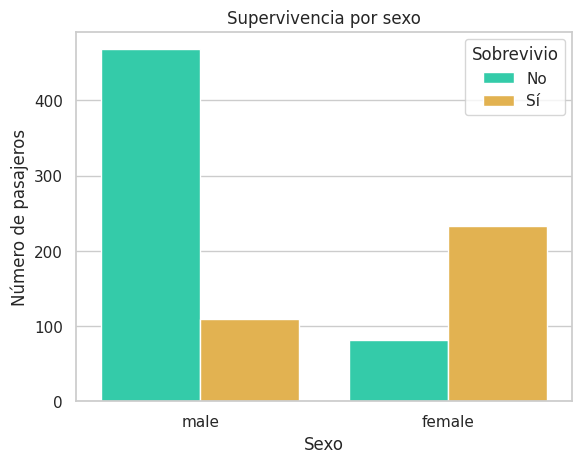

In [ ]:
sns.countplot(data=df, x="Sex", hue="Sobrevivio", palette="turbo")
plt.title("Supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.show()

---
**Histograma de edad**

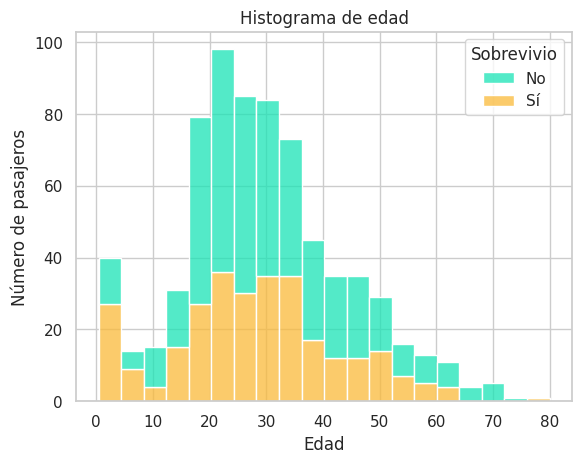

In [ ]:
sns.histplot(data=df, x="Age", hue="Sobrevivio", multiple="stack", palette="turbo")
plt.title("Histograma de edad")
plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.show()

---
**Violin: Tarifa vs supervivencia**

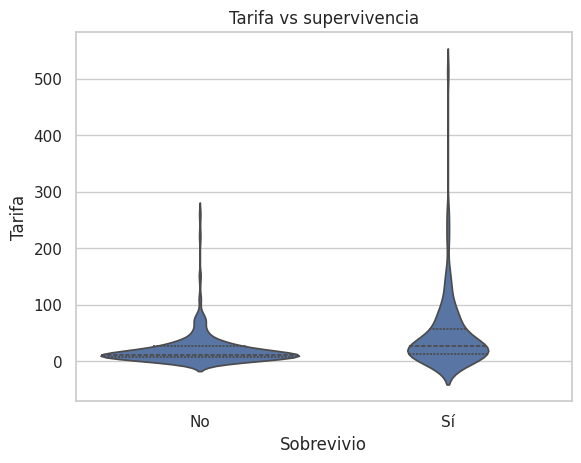

In [ ]:
sns.violinplot(data=df, x="Sobrevivio", y="Fare", inner='quartile')
plt.title("Tarifa vs supervivencia")
plt.xlabel("Sobrevivio")
plt.ylabel("Tarifa")
plt.show()

---
**Supervivencia por número de hermanos o conyugues**

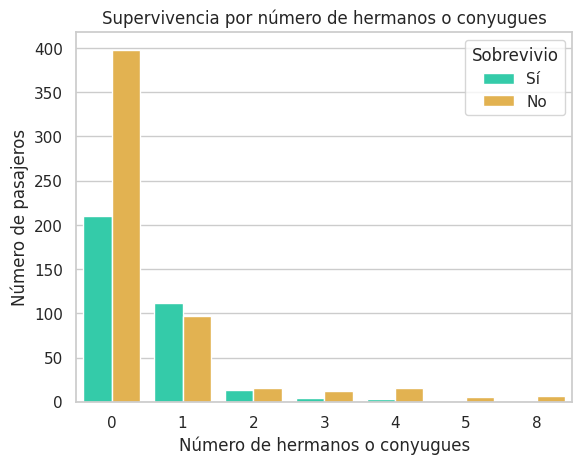

In [ ]:
sns.countplot(data=df, x="SibSp", hue="Sobrevivio", palette="turbo")
plt.title("Supervivencia por número de hermanos o conyugues")
plt.xlabel("Número de hermanos o conyugues")
plt.ylabel("Número de pasajeros")
plt.show()

---
**Probabilidad de sobrevivir por sexo y clase**

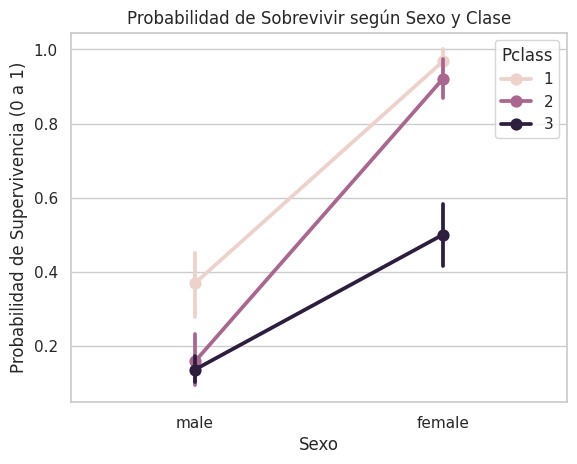

In [ ]:
sns.pointplot(data=df, x="Sex", y="Survived", hue="Pclass")
plt.title("Probabilidad de Sobrevivir según Sexo y Clase")
plt.xlabel("Sexo")
plt.ylabel("Probabilidad de Supervivencia (0 a 1)")
plt.show()

---
Mapa de calor de las correlaciones

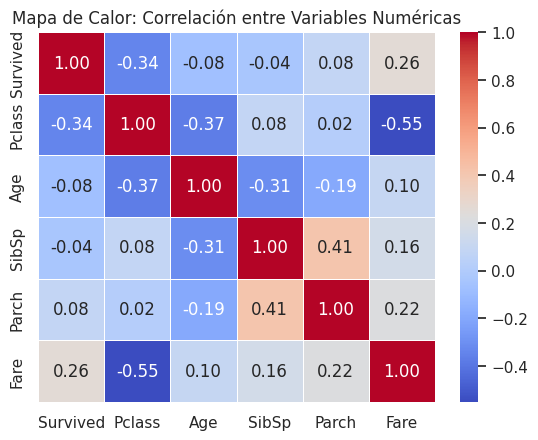

In [ ]:
columnas_numericas = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
datos_numericos = df[columnas_numericas]
correlacion = datos_numericos.corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación entre Variables Numéricas')
plt.show()

---
# **Tendencias o patrones básicos observados**




* La gran mayoría de muertos tenían boleto de tercera clase.
* La diferencia de muertos de la clase 1 a la clase 2 no es tan significativa.
* Intuyo que la tercera clase tiene la mayoría de bajas porque, en comparación con las otras dos clases, tiene muchísima más cantidad de personas.
* Más muertos hombres que mujeres.
* La mayoría de los pasajeros tenían entre 20 y 30 años.
* El pagar tiene algo de correlación con la supervivencia.
* Valores atípicos en las tarifas (Fare).
* Viajar con una familia pequeña aumenta las probabilidades de sobrevivir.





---
# **Limitaciones de la base de datos**
* Casi 20% de datos faltantes en la variable Age.
* La variable Cabin tiene un 77% de datos faltantes; por ende, no es posible saber la ubicación física del pasajero en el barco.
* El dataset solo contiene 891 muestras, gran diferencia a los más de 2000 pasajeros que llevó el Titanic.

---
# **Hipótesis iniciales para futuros análisis**



* Los pasajeros de primera clase tienen una tasa de supervivencia más alta sobre los pasajeros de tercera clase.
* Pagar mas (Fare) significa mas probabilidad de supervivencia.
* El género es el pronóstico más fuerte de supervivencia. Las mujeres tienen más probabilidad de sobrevivir frente a los hombres, sin importar su clase.
* El hombre joven (20/30 años) representa al grupo con mayor grado de mortalidad en el accidente.
* Los pasajeros que viajaban solos tienen una probabilidad más alta de morir frente a aquellos que viajaban con por lo menos 1 familiar o cónyuge.






# **Anotaciones sobre la primera exploración al DataSet**

* Puedo observar una posible relación en la probabilidad de muerte que tiene el pasajero de acuerdo a la clase que era al momento del hundimiento. Si bien la clase 3 (Pclass) tiene más cantidad de pasajeros que las clases 1 y 2, si juntamos la cantidad de muertos de las clases 1 y 2, no sobrepasan la cantidad de muertos de la clase 3.

* Observo una posible relación entre la supervivencia y el género de la persona, aunque esta no es clara del todo por la diferencia del número de pasajeros hombre vs mujer.

* Se proyecta que, para futuras fases de la metodología, se deba trabajar con la variable edad (Age) por su porcentaje de datos faltantes.

* Se observa que el tamaño de la familia pudo influir en la supervivencia, ya que los pasajeros que viajaban solos tuvieron una tasa de mortalidad más alta. Por otro lado, viajar con una familia pequeña (1 a 3 acompañantes) aumentó las probabilidades de sobrevivir.

* Se identificaron muchos valores atípicos en la variable de tarifa (Fare), con unos valores exorbitantes de más de 500, además de esto, se observa una posible correlación entre la variable de supervivencia (survived) y la tarifa pagada (Fare).

* Y por último, se detectó que la variable de Cabina (Cabin) tiene un alto porcentaje de faltantes (77%), por lo tanto, en futuras fases se deberá revisar qué hacer con esta variable.